# BlinkIT Grocery Data Analysis BY Pritam9952

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [8]:
df = pd.read_csv('BlinkIT Grocery Data.csv')

# Data Cleaning and Preprocessing

In [9]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [11]:
df.describe()

,Outlet Establishment Year,Item Visibility,Item Weight,Sales,Rating
count,8523.000000,8523.000000,7060.000000,8523.000000,8523.000000
mean,2016.450546,0.066132,12.857645,140.992783,3.965857
std,3.189396,0.051598,4.643456,62.275067,0.605651
min,2011.000000,0.000000,4.555000,31.290000,1.000000
25%,2014.000000,0.026989,8.773750,93.826500,4.000000
50%,2016.000000,0.053931,12.600000,143.012800,4.000000
75%,2018.000000,0.094585,16.850000,185.643700,4.200000
max,2022.000000,0.328391,21.350000,266.888400,5.000000


In [12]:
df.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

In [13]:
# Replacing in column 'Item_Fat_Content low fat , Lf with Low Fat AND reg with Regular

In [15]:
df['Item Fat Content'] = df['Item Fat Content'].replace({
    'low fat' : 'Low Fat',
    'LF' : 'Low Fat',
    'reg' : 'Regular'
})

In [16]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat'], dtype=object)

In [17]:
# Fill missing Item_Weight with median (grouped by Item_Identifier)

In [18]:
df['Item Weight'] = df.groupby('Item Identifier')['Item Weight'].transform(
    lambda x: x.fillna(x.median())
)

In [19]:
# Convert Outlet_Establishment_Year to age

In [20]:
current_year = 2023  # Assuming current year as 2023
df['Outlet Age'] = current_year - df['Outlet Establishment Year']

In [21]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating,Outlet Age
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0,11
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0,1
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0,7
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0,9
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0,8


# Exploratory Data Analysis (EDA)

In [22]:
sns.set_style('whitegrid')
plt.figure(figsize=(12,8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

# Sales Distribution

Text(0.5, 1.0, 'Sales Distribution')

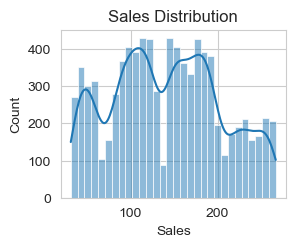

In [23]:
plt.subplot(2,2,1)
sns.histplot(df['Sales'],  bins = 30 , kde = True)
plt.title('Sales Distribution')

In [24]:
fig1 = px.histogram(
    df,
    x ='Sales',
    title = '<b> Sales Distribution </b>',
    nbins = 30
)
fig1.update_traces(
    marker = dict(line = dict(width = 1 , color = 'black')),
    selector = dict(type = 'histogram'),
    opacity = 0.8
)
fig1.update_layout(
   xaxis_title='Sales Amount',
    yaxis_title='Count of Items',
    bargap=0.2,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(
        family="Arial, sans-serif",
        size=12,
        color="RebeccaPurple"
    ),
    title_x=0.5,
    margin=dict(l=40, r=40, t=80, b=40),
    hovermode="x unified",
)
fig1.show(renderer = 'iframe_connected')

In [25]:
# To add a vertical line at mean sales
mean_sales = df['Sales'].mean()
fig1.add_vline(
    x=mean_sales, 
    line_width=2, 
    line_dash="dash", 
    line_color="yellow",
    annotation_text=f"Mean: {mean_sales:.2f}", 
    annotation_position="top right"
)

# To add a box plot below (subplot)
from plotly.subplots import make_subplots
fig = make_subplots(rows=2, cols=1)
fig.add_trace(fig1.data[0], row=1, col=1)
fig.add_box(x=df['Sales'], row=2, col=1)
fig.update_layout(height=800)
fig.show()

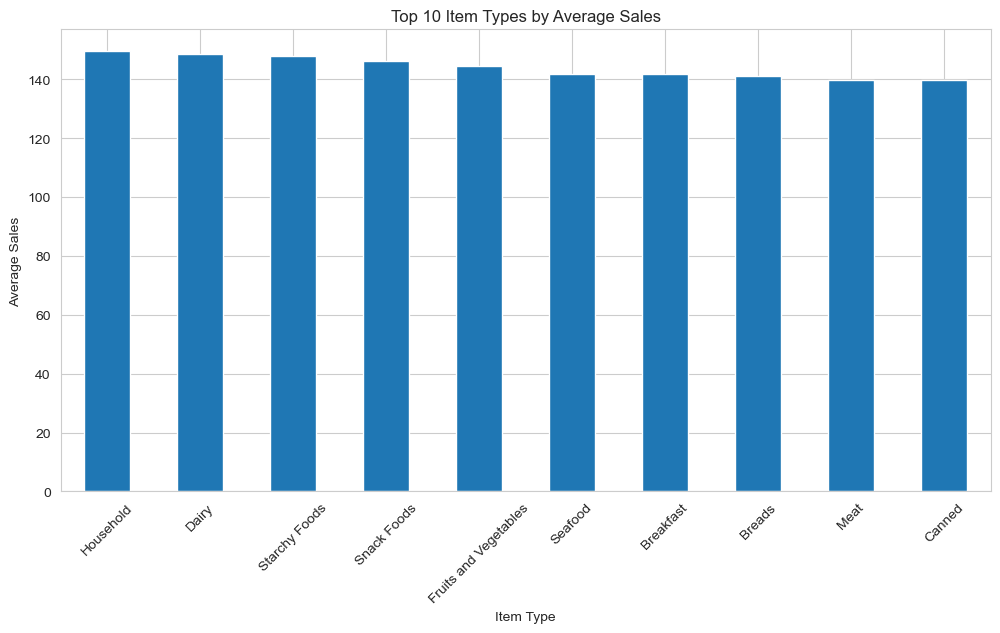

In [27]:
top_items_sales = df.groupby('Item Type')['Sales'].mean().nlargest(10)
plt.figure(figsize=(12, 6))
top_items_sales.plot(kind='bar')
plt.title('Top 10 Item Types by Average Sales')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.show()

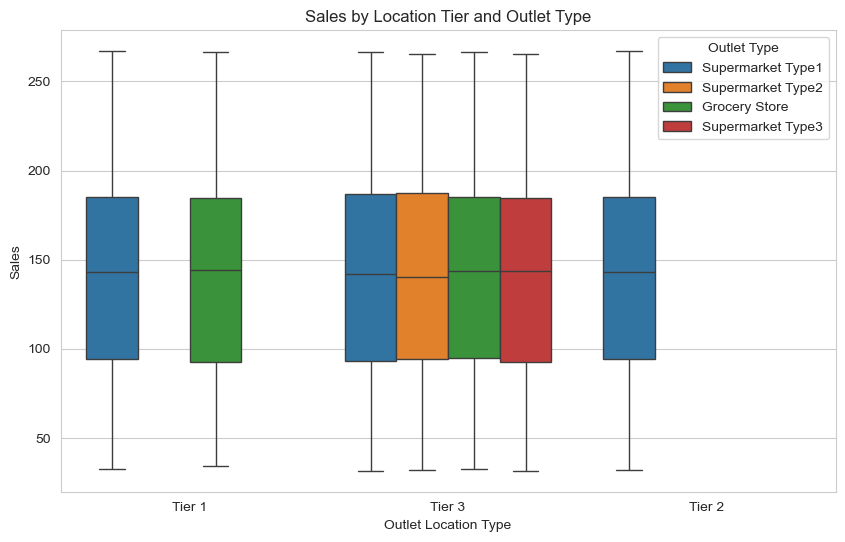

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outlet Location Type', y='Sales', hue='Outlet Type', data=df)
plt.title('Sales by Location Tier and Outlet Type')
plt.show()

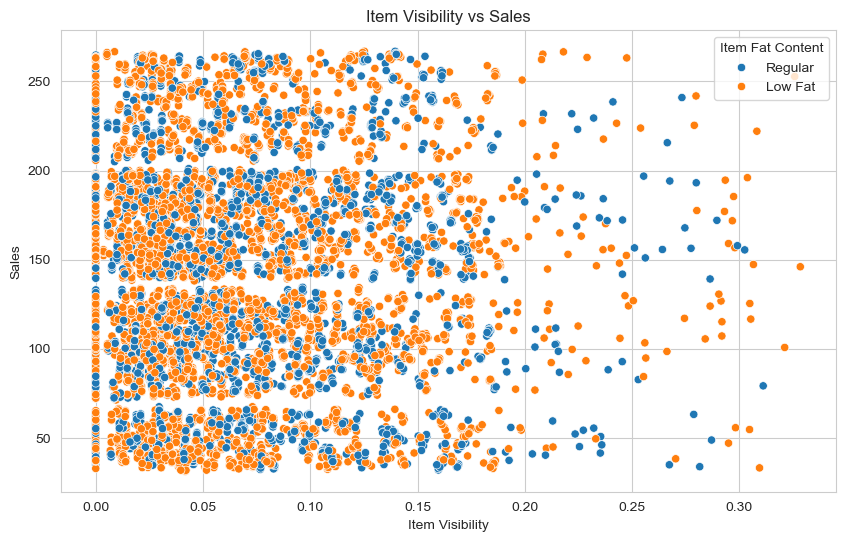

In [29]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Item Visibility', y='Sales', hue='Item Fat Content', data=df)
plt.title('Item Visibility vs Sales')
plt.show()

In [31]:
df_cleaned=df.to_csv('BlinkIT Grocery Data Cleaned.csv')